In [38]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import math

In [39]:
def get_frame(capture: cv2.VideoCapture, frame: int):
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame)
    ret, frame = capture.read()
    return frame

In [40]:
cap = cv2.VideoCapture('videoplayback (2).mp4')
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()

In [41]:
def remove_border(location):
    return (location[0], location[1])

def rescale(location):
    scale = 854.0 / 389.0
    return (location[0] * scale, location[1] * scale)

def add(a, b):
    return(a[0] + b[0], a[1] + b[1])

def cast(a):
    return(int(a[0]), int(a[1]))

In [42]:
scaling = 854.0 / 389.0
elixir_origin = (103,823)
elixir_size = (23,18)
card_origin = (86,737)
card_size = (66,83)
card_space = (7,7)

In [43]:
def quantize(frame, levels=4, display=False):
    step_size = 255 // (levels - 1) if display else 1
    quantized = np.clip((frame / 255 * (levels - 1)).astype(int), 0, levels - 1)
    quantized = (quantized * step_size).astype(np.uint8)
    
    return quantized

def downsize(frame, factor):
    return cv2.resize(frame, (frame.shape[1]//factor, frame.shape[0]//factor), interpolation=cv2.INTER_AREA)

def blur(frame, kernel):
    return cv2.GaussianBlur(frame, ksize=kernel, sigmaX=0, sigmaY=0)

def fill_fraction(img, fraction, intensity=127):
    h, w = img.shape[:2]
    cx, cy = w // 2, h // 2
    radius = int(np.hypot(cx, cy))

    steps = max(10, int(100 * fraction))
    angles = np.linspace(-math.pi/2, -math.pi/2 - 2*math.pi*fraction, steps)

    # Create a blank slice mask
    slice_mask = np.zeros_like(img, dtype=np.uint8)

    # Build polygon points
    points = [(cx, cy)] + [
        (int(cx + radius * math.cos(a)), int(cy + radius * math.sin(a)))
        for a in angles
    ]
    pts = np.array(points, np.int32).reshape((-1, 1, 2))

    # Fill the slice with the intensity
    if len(slice_mask.shape) == 3:  # color image
        cv2.fillPoly(slice_mask, [pts], (intensity, intensity, intensity))
    else:  # grayscale
        cv2.fillPoly(slice_mask, [pts], intensity)

    # Add the slice to the original image (with clipping)
    result = cv2.add(img, slice_mask)
    return result

In [44]:
def prep(image, downsize_factor = 4):
    shrunk = downsize(image, 2)
    blurred = blur(shrunk, (3,3))
    compressed = blurred
    return compressed

[[16  1]
 [32  1]
 [16 20]]
(41, 33, 3)


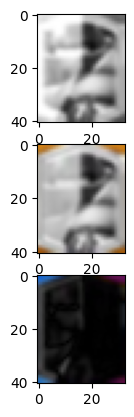

In [45]:
# cv2.imshow('Video Frame', frame)
def add_not_ready_filter(grayscale_image, elixir_cost, current_elixir):
    overlayed = fill_fraction(grayscale_image, (elixir_cost - current_elixir)/elixir_cost, 127)
    return overlayed

x_start = card_origin[0]
x_end = x_start + card_size[0]
y_start = card_origin[1]
y_end = y_start + card_size[1]
my_subimage = cv2.imread(f"cards/mega_knight-7.png")
my_subimage = add_not_ready_filter(cv2.cvtColor(cv2.cvtColor(my_subimage, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR), 7, 4)
fig, axes = plt.subplots(3)   
my_subimage = prep(my_subimage, 2) 
axes[0].imshow(my_subimage)
frame = get_frame(cap, 800) 
x_start = card_origin[0]
x_end = x_start + card_size[0]
y_start = card_origin[1]
y_end = y_start + card_size[1]
x_start += card_size[0] + card_space[0]
x_end += card_size[0] + card_space[0]
my_subimage2 = frame[int(y_start):int(y_end), int(x_start):int(x_end)]
my_subimage2 = prep(my_subimage2, 2)
axes[1].imshow(my_subimage2)
h, w = my_subimage2.shape[:2]
center = (w // 2, h // 2)
top    = (w // 2, 1)
right  = (w - 1, 1)
pts = np.array([top, right, center], dtype=np.int32).reshape((-1, 1, 2))
print(pts.reshape(-1, 2))
print(my_subimage2.shape)
diff = cv2.absdiff(my_subimage, my_subimage2)
# cv2.fillPoly(diff, [pts], color=[0, 255, 0])
axes[2].imshow(diff)
plt.show()



# Border : 10 x 10

In [46]:
def check_exists_add_otherwise(library, newimage, frame, template_threshold, grayscale_threshold, slice_size = 3):
    quantized_grayscaled = cv2.cvtColor(cv2.cvtColor(newimage, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
    if np.median(np.abs(newimage - quantized_grayscaled)) < grayscale_threshold: # If grayscale version (not ready to play)
        return

    # object: compressed image, original image, view count, timestamp
    shrunk = downsize(newimage, 4)
    blurred = blur(shrunk, (3,3))
    compressed = blurred
    cropped = compressed
    if(slice_size > 0):
        cropped = compressed[slice_size:-slice_size,slice_size:-slice_size]
    if(len(library) == 0):
        library.append([compressed, newimage, 1, frame])
        return
    
    for i, (image, _, _, _) in enumerate(library):
        res = cv2.matchTemplate(image,cropped,cv2.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv2.minMaxLoc(res)
        if max_val > template_threshold:
            library[i][2]+=1
            return
    library.append([compressed, newimage, 1, frame])

In [47]:
def get_images_in_hand(screenshot):
    hand = []
    for card in range(4):
        x_start = card_origin[0] + (card_size[0] + card_space[0]) * card
        x_end = x_start + card_size[0]
        y_start = card_origin[1]
        y_end = y_start + card_size[1]
        my_subimage = screenshot[int(y_start):int(y_end), int(x_start):int(x_end)]
        hand.append(my_subimage)
    return hand

def get_elixir_pic(screenshot):
    x_start = elixir_origin[0]
    x_end = x_start + elixir_size[0]
    y_start = elixir_origin[1]
    y_end = y_start + elixir_size[1]
    my_subimage = screenshot[int(y_start):int(y_end), int(x_start):int(x_end)]
    return my_subimage

In [48]:
# Go thru video and print all unique segments
def is_persistent(obj):
    count = obj[2]
    age = frame - obj[3]
    in_window = 50 < age < 150
    keep = count > 25 or not in_window
    # if not keep:
    #     is_persistent.i += 1
        # cv2.imwrite(f"imgs/culled/{count}_{is_persistent.i}_{obj[3]}.png", obj[1])
    return keep

is_persistent.i = 0

# seen_images = []

# for frame in range(0,1):
#     image = get_frame(cap, frame)
#     for card in range(4):
#         x_start = card_origin[0] + (card_size[0] + card_space[0]) * card
#         x_end = x_start + card_size[0]
#         y_start = card_origin[1]
#         y_end = y_start + card_size[1]
#         my_subimage = image[int(y_start):int(y_end), int(x_start):int(x_end)]
#         check_exists_add_otherwise(seen_images, my_subimage, frame, template_threshold=0.97, grayscale_threshold=5)

#     if frame % 100 == 0 and frame > 75 :
#         seen_images = list(filter(is_persistent, seen_images))
#         print(f"{frame}, {len(seen_images)}")

# seen_elixir = []

# for frame in range(2200,7400):
#     image = get_frame(cap, frame)
#     x_start = elixir_origin[0]
#     x_end = x_start + elixir_size[0]
#     y_start = elixir_origin[1]
#     y_end = y_start + elixir_size[1]
#     my_subimage = image[int(y_start):int(y_end), int(x_start):int(x_end)]
#     check_exists_add_otherwise(seen_elixir, my_subimage, frame, template_threshold=0.99, grayscale_threshold=5, slice_size=0)

#     if frame % 100 == 0 and frame > 75 :
#         seen_elixir = list(filter(is_persistent, seen_elixir))
#         print(f"{frame}, {len(seen_elixir)}")
# seen_images = list(filter(is_persistent, seen_images))
    # Starting @ timestep 200
    # Every 100 frames:
    # Get frames born between 150 and 50 frames ago
    # if they appear for < 25 frames
    # remove


In [49]:
# diff

# a = seen_images_human[3]
# b = seen_images_human[2]
# a_q = seen_images[3]
# b_q = seen_images[2]
# print(np.sum(np.abs(a_q - b_q)))
# fig, axes = plt.subplots(2)
# axes[0].imshow(a_q * 100)
# axes[1].imshow(b_q * 100)
# plt.show()

#  grayscale

# a_i=0
# a = seen_images[a_i][1]
# b = cv2.cvtColor(cv2.cvtColor(a, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
# print(np.median(np.abs(a - b)))
# fig, axes = plt.subplots(2)
# axes[0].imshow(a)
# axes[1].imshow(b)
# plt.show()

# edges
# a = seen_images[0]
# b = seen_images_human[0]
# t_lower = 25
# t_upper = 400
# edge = cv2.Canny(a, t_lower, t_upper)
# contours1, _ = cv2.findContours(edge, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# a_c = a.copy()
# contours = cv2.drawContours(a_c, contours1, -1, (0, 255, 0), 3)
# fig, axes = plt.subplots(2)
# axes[0].imshow(contours)
# axes[1].imshow(b)
# plt.show()

# template match
# a = seen_images[4][0]
# b = seen_images[9][0]
# b = b[3:-3,3:-3]
# res_b = cv2.matchTemplate(a,b,cv2.TM_CCOEFF_NORMED)
# min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res_b)
# print(min_val)
# print(max_val)
# fig, axes = plt.subplots(2)
# axes[0].imshow(a)
# axes[1].imshow(b)
# plt.show()

In [50]:

# i = 0
# for compressed, normal, count, time in seen_elixir:
#     i += 1
#     cv2.imwrite(f"imgs/{i}_{count}.png", normal)

In [51]:
def contours_in_image(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, image_thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    image_contours, hierarchy = cv2.findContours(image_thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    image_contours = sorted(image_contours, key=cv2.contourArea, reverse=True)[:3]
    return image_contours, hierarchy

# def cards_in_hand(image, dataset: dict):
#     fig, axes = plt.subplots(2, 4)
    
#     cards_h = get_images_in_hand(image)
#     for i, card_h in enumerate(cards_h):
#         card_h = blur(card_h[10:-25,5:-5], (9,9))
#         best_card, best_score, target, source, target_contours, source_contours = ("None", float('inf'), None, None, None, None)
#         card_h_contours, _ = contours_in_image(card_h)
#         for name, card in dataset.items():
#             card = blur(card[10:-25,5:-5], (9,9))
#             card_contours, _ = contours_in_image(card)
#             for card_h_contour in card_h_contours:
#                 for card_contour in card_contours:
#                     match_value = cv2.matchShapes(card_h_contour, card_contour, cv2.CONTOURS_MATCH_I1, 0.0)
#                     if (match_value < best_score):
#                         best_card = name
#                         best_score = match_value
#                         target = card_h
#                         source = card
#                         target_contours = card_h_contour
#                         source_contours = card_contour
#         print(f"Best match for card {i}: {best_card}, {best_score}")
#         if(target is not None and source is not None):
#             cv2.drawContours(target, target_contours, -1, (0, 255, 0), 2)
#             cv2.drawContours(source, source_contours, -1, (0, 255, 0), 2)
#             axes[0, i].imshow(target)
#             axes[1, i].imshow(source)
#     plt.show()

def current_elixir(image, dataset: dict):    
    elixir_pic = get_elixir_pic(image)
        
    card_h = elixir_pic[2:-2,2:-2]
    best_card, best_score = (None, 0)
    for name, card in dataset.items():
        res = cv2.matchTemplate(card,card_h,cv2.TM_CCOEFF_NORMED)
        _, max_val, _, _ = cv2.minMaxLoc(res)
        if max_val > best_score:
            best_card = name
            best_score = max_val
    if(best_score < 0.8):
        best_card = None
    return best_card

def cards_in_hand(image, dataset: dict, elixir):    
    cards_h = get_images_in_hand(image)
    detected_hand = []
    for card_h in cards_h:
        grayscaled = cv2.cvtColor(cv2.cvtColor(card_h, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
        is_gray =  np.median(np.abs(card_h - grayscaled)) < 5 # If grayscale version (not ready to play)
        
        card_h = prep(card_h, 2 if is_gray else 4)[4:-4,4:-4]
        best_card, best_score = (None, 0)
        for name, card in dataset.items():
            if(is_gray):
                card = cv2.cvtColor(cv2.cvtColor(card, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)
            if(is_gray and elixir is not None):
                cost = int(name.split("-")[1].split(".")[0])
                add_not_ready_filter(card, elixir_cost=cost, current_elixir=elixir)
            card = prep(card, 2 if is_gray else 4)
            res = cv2.matchTemplate(card,card_h,cv2.TM_CCOEFF_NORMED)
            _, max_val, _, _ = cv2.minMaxLoc(res)
            if max_val > best_score:
                best_card = name
                best_score = max_val
        if(is_gray and best_score > 0.4):
            detected_hand.append(f"gray_{best_card}")
        elif(best_score > 0.7):
            detected_hand.append(best_card)
        else:
            detected_hand.append(None)
    return detected_hand
    


In [52]:
entries = os.listdir("cards/")
deck = {}
for filename in entries:
    deck[filename] = cv2.imread(f"cards/{filename}")

entries = os.listdir("elixir/")
elixirs = {}
for filename in entries:
    elixirs[filename] = cv2.imread(f"elixir/{filename}")

In [53]:
h0, w0 = get_frame(cap, 0).shape[:2]
writer = cv2.VideoWriter("hand.mp4", 0, 30, (w0, h0), isColor=True)
old_hand = [None, None, None, None]

for frame in range(250, 1500):
    hand_diff = [None, None, None, None]
    if(frame % 2 == 1): continue
    img = get_frame(cap, frame)
    elixir = current_elixir(img, elixirs)
    if elixir is not None:
        elixir = elixir.split('.')[0]
        elixir = int(elixir)
    my_hand = cards_in_hand(img, deck, elixir)
    for i, card in enumerate(my_hand):
        if card is None or card == "empty.png":
            continue
        gray = "gray" in card
        if(gray):
            card = "_".join(card.split('_')[1:])
        name = card.split('.')[0]
        if(old_hand[i] != my_hand[i]):
            old_hand[i] = my_hand[i]
            hand_diff[i] = my_hand[i]
        cv2.putText(img, name, (card_origin[0] + i * (card_space[0] + card_size[0]), card_origin[1]- i * 8), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,255,0) if not gray else (255, 255, 255), 2)

    # diff_count = reduce(lambda acc, item: acc + 1 if item is not None, hand_diff)
    
    cv2.putText(img, str(elixir), (elixir_origin[0], elixir_origin[1]), cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255) if not gray else (255, 255, 255), 2)
    writer.write(img)
    if(frame % 100 == 0):
        print(frame)

writer.release()
    

300
400
500
600
700
800
900
1000
1100
1200
1300
1400
